# 3D Area Projections

In [1]:
import os, sys, imio, tifffile
from skimage.io import imread, imread_collection, concatenate_images
from braintracer.braintracer import file_management as btf
from braintracer.braintracer import analysis as bt
from braintracer.braintracer import plotting as btp
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import center_of_mass
from skimage.transform import resize
from tqdm import tqdm

In [2]:
## DEFINE YOUR EXPERIMENT
bt.postsyn_region = 'IO' # You must set a starter region to use some features
# For quantifications comparing pre and postsynaptic cell populations, you must set the following:
bt.postsyn_ch = 'r' # The channel(s) containing starter cells (postsynaptics)
bt.presyn_ch = 'r' # The channel(s) containing input cells (presynaptics)
bt.presyn_regions_exclude = [''] # Presynaptic cells are the total cells in presyn_ch - (postsyn_region + presyn_regions_exclude)

bt.channel_colours = ['r','g','b'] # ordered list of colours channels will take ['r','g','b'] by default
bt.network_name = 'bt14' # default is Unet
bt.grouped = False #True # True by default, set to False if you only have one group
bt.debug = False # False by default

In [3]:
def open_image(name):
    path = f'braintracer/registered_atlases/atlas_{name}_{bt.postsyn_ch}.tiff'
    #path = 'C:/Users/Sam/.brainglobe/allen_mouse_io_10um_v1.0/annotation_test.tiff'
    assert os.path.isfile(path), f'Please provide binarised stack coordinates at {path}'
    coordinates = imread(path)
    return coordinates

In [4]:
# TODO: insert this back into plotting.py after analysis
def _get_projection(area, dset_name=None, slice_details=None, padding=None, axis=0):
    if isinstance(area, list):
        areas = []
        for i in area:
            parent, children = bt.children_from(i, depth=0)
            areas = areas + [parent] + children
    else:
        area = 83 if area in ['Rostral-medial IO', 'Rostral-lateral IO', 'Caudal-medial IO', 'Caudal-lateral IO', 'Medial IO', 'Lateral IO', 'Rostral IO', 'Caudal IO'] else area
        parent, children = bt.children_from(area, depth=0)
        areas = [parent] + children
    
    reg_atlas = open_image(dset_name) if dset_name is not None else bt.atlas
    if slice_details is not None:
        atlas_total = reg_atlas.shape[0]
        end = int(atlas_total - (slice_details['start'] / slice_details['total'] * atlas_total))
        start = int(atlas_total - (slice_details['end'] / slice_details['total'] * atlas_total))
        reg_atlas = reg_atlas[start:end,:,:]
    
    atlas_ar = np.isin(reg_atlas, areas)

    nz = np.nonzero(atlas_ar)
    z_min, y_min, x_min = nz[0].min(), nz[1].min(), nz[2].min()
    z_max, y_max, x_max = nz[0].max()+1, nz[1].max()+1, nz[2].max()+1
    
    if padding is not None:
        z_min, y_min, x_min = z_min - padding, y_min - padding, x_min - padding
        z_max, y_max, x_max = z_max + padding, y_max + padding, x_max + padding
    if (z_max > atlas_ar.shape[0]) or (y_max > atlas_ar.shape[1]) or (x_max > atlas_ar.shape[2]):
        print('Watch out! Remove padding for areas that touch the edge of the atlas.')
    if (z_min < 0) or (y_min < 0) or (x_min < 0):
        print('Watch out! Remove padding for areas that touch the edge of the atlas.')
    if bt.debug:
        print('x:'+str(x_min)+' '+str(x_max)+' y:'+str(y_min)+' '+str(y_max)+' z:'+str(z_min)+' '+str(z_max))
    if padding is not None:
        atlas_ar = atlas_ar[z_min : z_max,
                             y_min : y_max,
                             x_min : x_max]

    projection = atlas_ar.any(axis=2-axis)
    projection = projection.astype(int)
    projection = projection.T if axis == 0 else projection # side-on orientation does not need axis swapping
    return projection, (x_min, y_min, z_min), (x_max, y_max, z_max)

In [5]:
def full_frame(width=None, height=None):
    import matplotlib as mpl
    mpl.rcParams['savefig.pad_inches'] = 0
    figsize = None if width is None else (width, height)
    fig = plt.figure(figsize=figsize)
    ax = plt.axes([0,0,1,1], frameon=False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.autoscale(tight=True)
    return fig, ax

In [6]:
def label_centre_of(projection, area_name, ax):
    hemisphere_width = projection.shape[1] // 2
    projection_hemisphere = projection[:, hemisphere_width:]
    centre_y, centre_x = center_of_mass(projection_hemisphere)
    centre_x += hemisphere_width
    ax.text(centre_x, centre_y, f'{area_name}', color='k', fontsize=7, ha='center', va='center')

In [7]:
def max_image_from_stack(stack):
    max_image = stack[0].copy()
    
    for img in tqdm(stack[1:], desc="Max projection"):
        np.maximum(max_image, img, out=max_image)

    return max_image

In [8]:
def _get_slice_with_projection(path_to_full_res_slices, slice_details):
    all_files = os.listdir(path_to_full_res_slices)
    all_images = [f for f in all_files if f.lower().endswith(('.tif'))]
    
    selected_images = all_images[slice_details['start']-1 : slice_details['end']]
    selected_image_paths = [path_to_full_res_slices + os.path.sep + f_name for f_name in selected_images]

    stack = imread_collection(selected_image_paths)
    max_im = max_image_from_stack(stack)
    return max_im

## Setup

In [9]:
def do_slice(NAME, path_to_full_res_slices, areas, projcol, slice_details, vmin, vmax, flip=False):
    f, ax = full_frame()

    max_im = _get_slice_with_projection(path_to_full_res_slices, slice_details)

    sorted_pixels = np.sort(max_im.flatten())
    vmin = np.percentile(sorted_pixels, vmin) # xth percentile
    vmax = np.percentile(sorted_pixels, vmax)

    ax.imshow(max_im, cmap='gray_r', vmin=vmin, vmax=vmax)

    for area in areas:
        projection = _get_projection(area, NAME, slice_details=slice_details, axis=2)[0]
        if flip:
            projection = projection[:,::-1]
        projection_resized = resize(projection, max_im.shape, preserve_range=True, anti_aliasing=False)
        contour = ax.contour(projection_resized, colors=projcol, levels=[0.5], alpha=0.5, linewidths=0.3)
        label_centre_of(projection_resized, area, ax)

    ax.set_aspect('equal')
    start = slice_details['start']
    end = slice_details['end']
    btf.save(f'{NAME}_{areas}_{start}-{end}', dpi=1000, as_type='pdf')
    plt.show()

## Figure 5 + 7

In [11]:
configs = [
{ # fig 7
'NAME': 'SC014',
'slice_config': {'start': 1600, 'end': 1602, 'total': 2602},
'drive': ['I:', 1],
'areas': ['VAL','PCN','VM','VPL'],
'threshold': [97, 99.95]
},
{
'NAME': 'SC022',
'slice_config': {'start': 1481, 'end': 1483, 'total': 2600},
'drive': ['G:', 1],
'areas': ['VAL','PCN','VM','VPL'],
'threshold': [95, 99.96]
},
{ # fig 5
'NAME': 'SC030',
'slice_config': {'start': 370, 'end': 480, 'total': 2464},
'drive': ['G:', 3],
'areas': ['CBX','SIM'],
'threshold': [99, 99.99]
},
{
'NAME': 'SC031',
'slice_config': {'start': 630, 'end': 810, 'total': 2640},
'drive': ['G:', 3],
'areas': ['CBX','CUL4, 5'],
'threshold': [95, 99.96]
},
{
'NAME': 'SC010',
'slice_config': {'start': 200, 'end': 490, 'total': 2514},
'drive': ['H:', 1],
'areas': ['IO'],
'threshold': [90, 100]
},
{
'NAME': 'SC012',
'slice_config': {'start': 230, 'end': 480, 'total': 2642},
'drive': ['H:', 1],
'areas': ['IO'],
'threshold': [99, 100]
},
]

## Fig 5 Supplement

In [11]:
configs = [
{
'NAME': 'SC030',
'slice_config': {'start': 1200, 'end': 1330, 'total': 2464}, # 1140 - 1220 for PAG
'drive': ['G:', 1],
'areas': ['PAG','MA3','RN','INC','ND'],
'threshold': [90, 99.99]
},
#{
#'NAME': 'SC030',
#'slice_config': {'start': 1950, 'end': 2110, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['MO'],
#'threshold': [90, 99.99]
#},
#{
#'NAME': 'SC030',
#'slice_config': {'start': 1375, 'end': 1480, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['TH'],
#'threshold': [90, 99.99]
#},
#{
#'NAME': 'SC030',
#'slice_config': {'start': 680, 'end': 800, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['P','PRNc','PRNr'],
#'threshold': [90, 99.99]
#},
#{
#'NAME': 'SC030',
#'slice_config': {'start': 380, 'end': 510, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['CBN'],
#'threshold': [90, 99.99]
#},
#{
#'NAME': 'SC030',
#'slice_config': {'start': 1120, 'end': 1240, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['SCm'],
#'threshold': [90, 99.99]
#},
{
'NAME': 'SC031',
'slice_config': {'start': 1250, 'end': 1370, 'total': 2640}, # PAG 900 - 1050
'drive': ['G:', 1],
'areas': ['PAG','MA3','RN','INC','ND'],
'threshold': [70, 99.99]
},
{
'NAME': 'SC031',
'slice_config': {'start': 1990, 'end': 2100, 'total': 2640},
'drive': ['G:', 1],
'areas': ['MO'],
'threshold': [97, 100]
},
{
'NAME': 'SC031',
'slice_config': {'start': 1420, 'end': 1470, 'total': 2640},
'drive': ['G:', 1],
'areas': ['TH'],
'threshold': [90, 99.96]
},
{
'NAME': 'SC031',
'slice_config': {'start': 650, 'end': 800, 'total': 2640},
'drive': ['G:', 1],
'areas': ['P','PRNc','PRNr'],
'threshold': [97, 100]
},
{
'NAME': 'SC031',
'slice_config': {'start': 430, 'end': 570, 'total': 2640},
'drive': ['G:', 1],
'areas': ['CBN'],
'threshold': [70, 99.99]
},
{
'NAME': 'SC031',
'slice_config': {'start': 1060, 'end': 1210, 'total': 2640},
'drive': ['G:', 1],
'areas': ['SCm'],
'threshold': [70, 99.99]
},
]

## Figure 2

In [14]:
configs = [
{
'NAME': 'SC013',
'slice_config': {'start': 90, 'end': 180, 'total': 2082},
'drive': ['I:', 1],
'areas': ['IO'],
'threshold': [90, 99.9]
},
{
'NAME': 'SC013',
'slice_config': {'start': 450, 'end': 550, 'total': 2082},
'drive': ['I:', 1],
'areas': ['CBX','SIM'],
'threshold': [0, 99.999]
},
{
'NAME': 'SC013',
'slice_config': {'start': 380, 'end': 530, 'total': 2082},
'drive': ['I:', 1],
'areas': ['CBN'],
'threshold': [90, 98]
},
{
'NAME': 'SC014',
'slice_config': {'start': 140, 'end': 400, 'total': 2602},
'drive': ['I:', 1],
'areas': ['IO'],
'threshold': [99, 99.9]
},
{
'NAME': 'SC014',
'slice_config': {'start': 410, 'end': 770, 'total': 2602},
'drive': ['I:', 1],
'areas': ['CBX','CUL4, 5'],
'threshold': [0, 99.999]
},
{
'NAME': 'SC014',
'slice_config': {'start': 810, 'end': 920, 'total': 2602},
'drive': ['I:', 1],
'areas': ['P','PG','TRN'],
'threshold': [95, 99.8]
},
{
'NAME': 'SC014',
'slice_config': {'start': 450, 'end': 580, 'total': 2602},
'drive': ['I:', 1],
'areas': ['CBN'],
'threshold': [90, 97]
},
{
'NAME': 'SC015',
'slice_config': {'start': 700, 'end': 870, 'total': 2440},
'drive': ['I:', 1],
'areas': ['P','PG','TRN'],
'threshold': [95, 99]
},
]

## Fig. 2 Supplementary

In [16]:
configs = [
{
'NAME': 'SC013',
'slice_config': {'start': 730, 'end': 940, 'total': 2082},
'drive': ['I:', 1],
'areas': ['PAG'],
'threshold': [90, 99]
},
{
'NAME': 'SC013',
'slice_config': {'start': 400, 'end': 500, 'total': 2082},
'drive': ['I:', 1],
'areas': ['VNC'],
'threshold': [90, 95]
},
{
'NAME': 'SC013',
'slice_config': {'start': 163, 'end': 245, 'total': 2082},
'drive': ['I:', 1],
'areas': ['LRN'],
'threshold': [90, 99]
},
{
'NAME': 'SC013',
'slice_config': {'start': 390, 'end': 410, 'total': 2082},
'drive': ['I:', 1],
'areas': ['ICB'],
'threshold': [90, 97]
},
{
'NAME': 'SC015',
'slice_config': {'start': 700, 'end': 870, 'total': 2440},
'drive': ['I:', 1],
'areas': ['TRN'],
'threshold': [95, 99]
},
{
'NAME': 'SC014',
'slice_config': {'start': 780, 'end': 1000, 'total': 2602},
'drive': ['I:', 1],
'areas': ['PAG'],
'threshold': [93, 99]
},
{
'NAME': 'SC014',
'slice_config': {'start': 490, 'end': 570, 'total': 2602},
'drive': ['I:', 1],
'areas': ['VNC'],
'threshold': [90, 97]
},
{
'NAME': 'SC014',
'slice_config': {'start': 125, 'end': 290, 'total': 2602},
'drive': ['I:', 1],
'areas': ['LRN'],
'threshold': [95, 99.7]
},
{
'NAME': 'SC014',
'slice_config': {'start': 471, 'end': 504, 'total': 2602},
'drive': ['I:', 1],
'areas': ['ICB'],
'threshold': [93, 99]
},
{
'NAME': 'SC014',
'slice_config': {'start': 810, 'end': 920, 'total': 2602},
'drive': ['I:', 1],
'areas': ['TRN'],
'threshold': [95, 99]
},
]

## Dopamine Supplementary

In [13]:
configs = [
#{
#'NAME': 'SC033', # or SC032 VTA 1050-1190 / 2360
#'slice_config': {'start': 1030, 'end': 1230, 'total': 2464},
#'drive': ['G:', 1],
#'areas': ['VTA'],
#'threshold': [0, 100]
#},
{
'NAME': 'SC032',
'slice_config': {'start': 150, 'end': 450, 'total': 2360},
'drive': ['G:', 1],
'areas': ['IO'],
'threshold': [20, 100]
},
]

## RUN

Max projection: 100%|█████████████████████████████████████████████████████████████| 130/130 [00:03<00:00, 35.01it/s]


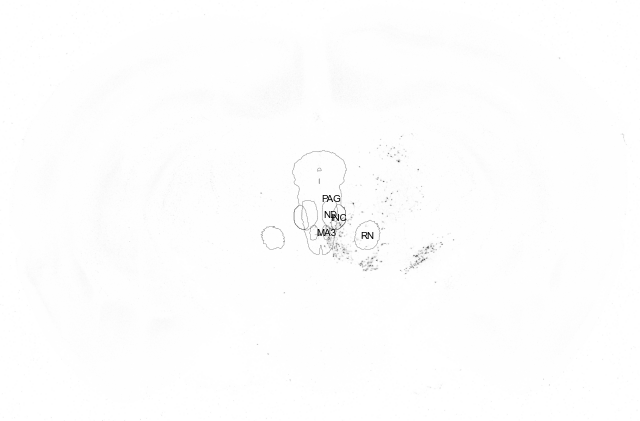

Max projection: 100%|█████████████████████████████████████████████████████████████| 120/120 [00:03<00:00, 36.79it/s]


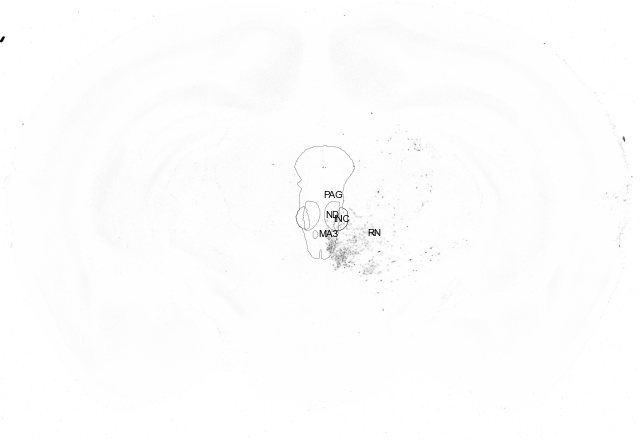

Max projection: 100%|█████████████████████████████████████████████████████████████| 110/110 [00:03<00:00, 34.51it/s]


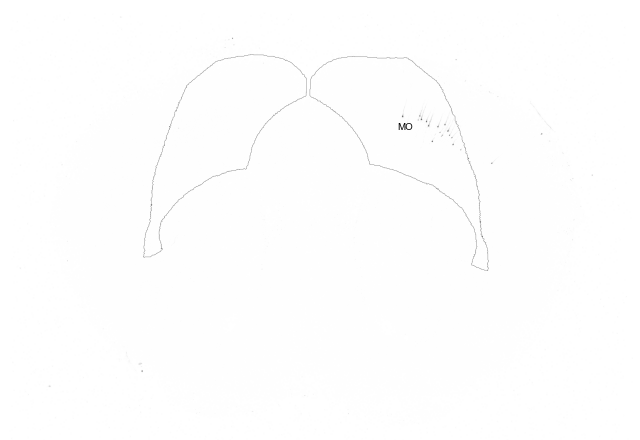

Max projection: 100%|███████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 34.00it/s]


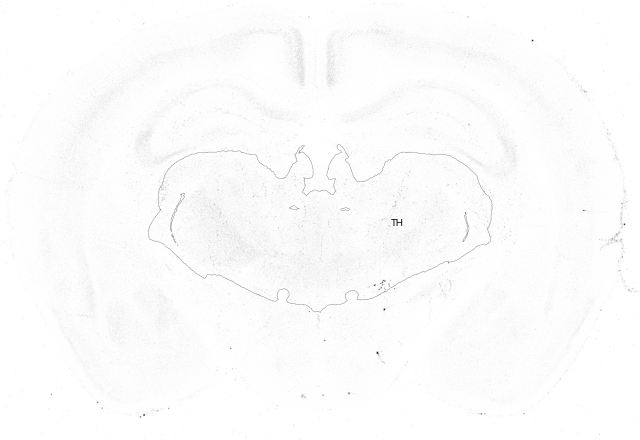

Max projection: 100%|█████████████████████████████████████████████████████████████| 150/150 [00:15<00:00,  9.40it/s]


KeyboardInterrupt: 

In [12]:
for config in configs:
    (name, slice_details, drive, areas, threshold) = config.values()
    path_to_full_res_slices = drive[0] + os.path.sep + name + os.path.sep + str(drive[1])
    flip = name == 'SC014'
    do_slice(name, path_to_full_res_slices, areas, projcol='k', slice_details=slice_details, vmin=threshold[0], vmax=threshold[1], flip=flip)